# Librerías

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from scipy.stats import shapiro, ttest_rel, wilcoxon, t, chi2_contingency
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import OLSInfluence
import math
from statsmodels.stats.power import TTestPower
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from statsmodels.formula.api import mixedlm
from scipy.stats import bootstrap

## Semilla

In [41]:
np.random.seed(42)

# Cargo los datos

In [42]:
#!wget https://raw.githubusercontent.com/bitazaratustra/proyecto_gv/main/data/base_ecocardio.csv

df = pd.read_csv('../data/base_ecocardio_final.csv')
df.shape

(76, 85)

In [4]:
# delete_cols = [
#     'rumble','DIAL DESD', 'DiastolMITRAL', 'Id1', 'Id', 'ConMS 1', 'VD global', 'POR1', 'Cav 1', 'CONG', 'CEmodsev', 'SUPRAH', 'DIASTOL', 'FEVI',
#     'FAV', 'bal 1500', 'bal 1500-3000', 'bal 3000', 'SC', 'SIV', 'PP',
#     'AD dil', 'VD1dil', 'VD2dil', 'VD3dil', 'derra', 'TEy'
# ]

# df.drop(columns=delete_cols, inplace=True)

In [43]:
var_demograficas = ["SEX", "EDAD", "HTA", "DBT", "DLP", "AHF", "TBQ", "Acceso"]
var_medicacion = ["BB", "BCA", "IECA", "ARA II", "ARNI", "MRA", "SGLT", "INSULINA"]
var_antropometricas = ["PESO", "TALLA", "HTO", "HB", "ALBUMIN", "KtV", "BALANCE"]

var_estaticas = var_demograficas + var_medicacion + var_antropometricas

var_categoricas = ['NAGUE +','DisfTEI','Disf TAPSE','Disf FAC','Disf Stis','IT','CAVA','PORT','Eeprim VD 6']

In [44]:
encoder = LabelEncoder()
# ordinal = OrdinalEncoder()


for col in var_categoricas:
    df[col] = df[col].where(df[col].isna(), encoder.fit_transform(df[col].values.astype(str)))
    
var_numericas = list(set(df.columns.to_list()) - set(var_categoricas) - set(var_estaticas))

In [45]:
df_pre = df[df['POSDIAL'] == 0]
df_pos = df[df['POSDIAL'] == 1]

## Apuntes

In [9]:
df[(df['IT'] != 0) & (df['vel it'].isna())]

# El paciente 9 tiene diagnosticos de IT pero no se pudo medir PSAP, vel it, y etc. y calculos derivados.
# Por problemas tecnicos no se realizo la medicion de los parametros relacionados con ls IT en el paciente 9.
# Tapse no se mide por carecer de la ventana apropiada
# 

,Unnamed: 0,Paciente,NAGUE +,vel it,Eeprim,AI vol index,SEX,EDAD,POSDIAL,PSAP,...,VD1,VD2,VD3,VCImin,Colap,Ssup,Dsup,SFF,Portmx,Portmin
16,16,9,1,NaN,17.6,58.6,F,51,1,NaN,...,34.0,35.0,77.0,8,50,31,28,52,16,14
17,17,9,1,NaN,25.5,58.6,F,51,0,NaN,...,36.0,38.0,85.0,9,44,38,34,53,25,19


# EDA

In [46]:
pin_vars = ['SEX', 'HTA', 'DBT', 'DLP', 'AHF', 'TBQ', 'BB', 'BCA', 'IECA', 'ARA II', 'ARNI', 'MRA', 'SGLT', 'INSULINA']


bins = [0, 30, 45, 60, 75, 100]
labels = ['18-30', '31-45', '46-60', '61-75', '76+']
df['Edad_Rango'] = pd.cut(df['EDAD'], bins=bins, labels=labels, right=False)

df_freq = df[df['POSDIAL'] == 1]


def get_freq_table(var):
    freq = df_freq[var].value_counts()
    percentage = df_freq[var].value_counts(normalize=True) * 100
    return freq, percentage


table1_data = []


for var in categorical_vars:
    freq, percentage = get_freq_table(var)


    if var == 'SEX':
        categories = {'F': 'Mujer'}
    elif var == 'HTA':
        categories = {1: 'HTA'}
    elif var == 'DBT':
        categories = {1: 'Diabetes'}
    elif var == 'DLP':
        categories = {1: 'Dislipidemia'}
    elif var == 'AHF':
        categories = {1: 'AHF'}
    elif var == 'TBQ':
        categories = {1: 'Tabaquismo'}
    elif var == 'BB':
        categories = {1: 'BB'}
    elif var == 'BCA':
        categories = {1: 'BCA'}
    elif var == 'IECA':
        categories = {1: 'IECA'}
    elif var == 'ARA II':
        categories = {1: 'ARA II'}
    elif var == 'ARNI':
        categories = {1: 'ARNI'}
    elif var == 'MRA':
        categories = {1: 'MRA'}
    elif var == 'SGLT':
        categories = {1: 'SGLT'}
    elif var == 'INSULINA':
        categories = {1: 'INSULINA'}

    else:
        categories = {}


    for category, freq_val in freq.items():
        if category in categories:
            category_name = categories.get(category, category)
            table1_data.append([category_name, freq_val, f"{percentage[category]:.2f}%"])


    missing_categories = set(categories.values()) - set(freq.index)
    for missing_category in missing_categories:

        table1_data.append([missing_category, 0, "0.00%"])

age_freq, age_percentage = get_freq_table('Edad_Rango')
for age, freq_val in age_freq.items():
    table1_data.append([f"Edad {age}", freq_val, f"{age_percentage[age]:.2f}%"])

table1 = pd.DataFrame(table1_data, columns=["Categoría", "Frecuencia Abs", "Frecuencia Relativa (%)"])

table1 = table1[table1["Frecuencia Abs"] > 0]
df.drop(columns='Edad_Rango', inplace=True)
table1

,Categoría,Frecuencia Abs,Frecuencia Relativa (%)
0,Mujer,15,39.47%
2,HTA,28,75.68%
4,Diabetes,11,28.95%
6,Dislipidemia,3,7.89%
9,Tabaquismo,5,13.16%
11,BB,8,21.05%
13,BCA,9,23.68%
15,IECA,6,15.79%
17,ARA II,9,23.68%
19,ARNI,1,2.63%


In [11]:
# def plot_categorical(df, variables, titulo=None, figsize=(20, 15)):

#     sns.set_theme(style="whitegrid")
#     palette = sns.color_palette("Blues_d", n_colors=3)
#     plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
    
#     n_vars = len(variables)
#     cols = 3
#     rows = (n_vars + cols - 1) // cols
#     fig, axs = plt.subplots(rows, cols, figsize=figsize)
#     fig.subplots_adjust(hspace=0.4, wspace=0.3)
    
#     axs = axs.flatten()
    
#     for i, var in enumerate(variables):
#         counts = df[df['Categoría'].isin([var])]
#         if not counts.empty:
#             abs_freq = counts['Frecuencia Abs'].values[0]
#             rel_freq = counts['Frecuencia Relativa (%)'].values[0]
            
#             ax = axs[i]
#             bars = ax.bar([var], [abs_freq], color=palette[1], alpha=0.85)
            
#             ax.set_title(var, fontsize=14, pad=10)
#             ax.set_ylabel('Frecuencia Absoluta', fontsize=12)
#             ax.tick_params(axis='x', rotation=45)
            
#             ax.annotate(f'{rel_freq}%', 
#                        xy=(bars[0].get_x() + bars[0].get_width()/2, abs_freq),
#                        xytext=(0, 3), textcoords='offset points',
#                        ha='center', va='bottom', fontsize=11)
            
#             sns.despine(left=True, bottom=True)
            
#     for j in range(i+1, len(axs)):
#         axs[j].axis('off')
    
#     if titulo:
#         fig.suptitle(titulo, y=1.02, fontsize=16)
    
#     return fig

# def plot_age_distribution(df, figsize=(10, 6)):
#     age_data = df[df['Categoría'].str.startswith('Edad')]
#     age_data = age_data.copy()
#     age_data['Edad'] = age_data['Categoría'].str.replace('Edad ', '')
#     age_order = ['18-30', '31-45', '46-60', '61-75', '76+']
    
#     sns.set_theme(style="whitegrid")
#     plt.rcParams.update({'font.size': 12})
#     palette = sns.color_palette("Greys_r", n_colors=5)
    
#     fig, ax = plt.subplots(figsize=figsize)
    
#     sns.barplot(x='Edad', y='Frecuencia Abs', data=age_data, 
#                 order=age_order, palette=palette, ax=ax, alpha=0.85)
    
#     ax.set_title('Distribución por Grupos de Edad', fontsize=14, pad=15)
#     ax.set_xlabel('Grupo de Edad', fontsize=12)
#     ax.set_ylabel('Frecuencia Absoluta', fontsize=12)
#     ax.tick_params(axis='x', rotation=45)
    
#     for p in ax.patches:
#         height = p.get_height()
#         ax.annotate(f'{height:.0f}',
#                     xy=(p.get_x() + p.get_width()/2, height),
#                     xytext=(0, 3), textcoords='offset points',
#                     ha='center', va='bottom', fontsize=11)
    
#     sns.despine(left=True, bottom=True)
#     return fig


# plot_categorical(table1, categorical_vars, titulo=None, figsize=(20, 15))
# plot_age_distribution(table1, figsize=(10, 6))

In [12]:
# variables_ = [
#     'vel it', 'Eeprim', 'AI vol index', 'TapPsap', 'grIT', 'StisVD', 'FEy',
#     'EA VD', 'EtisVD', 'Eeprim VD', '%fac', 'SFF', 'TAPSE', 'TEI', 'FAC', 'TAM',
#     'TAD', 'TAS', 'Tdec', 'VCImax', 'EVD', 'A VD', 'Eprim', 'FC', 'DDVI', 'IDDVI',
#     'DSVI', 'VTI', 'GC', 'IC', 'VS', 'IVS', 'IMVI', 'VD1', 'VD2', 'VD3', 'VCImin',
#     'Colap', 'Ssup', 'Dsup', 'PSAP', 'BALANCE', 'KtV', 'Anillo', 'Portmx', 'Portmin'
# ]


# static_cols = [
#     'Paciente', 'POSDIAL', 'Acceso', 'SEX', 'EDAD', 'HTA', 'DBT', 'DLP', 'AHF',
#     'TBQ', 'BB', 'BCA', 'IECA', 'PESO','TALLA', 'ARA II', 'ARNI', 'MRA', 'SGLT',
#     'INSULINA', 'HTO', 'HB', 'ALBUMIN'
# ]

# covariates = [
#               'Acceso', 'SEX', 'HTA', 'DBT', 'DLP', 'AHF',
#               'TBQ', 'BB', 'BCA', 'IECA', 'ARA II', 'ARNI', 'MRA', 'SGLT',
#               'INSULINA'
#             ]

## Nague +

Frecuencias Pre-Diálisis:
NAGUE +
1    22
0    16
Name: count, dtype: int64

Proporciones Pre-Diálisis:
NAGUE +
1    0.578947
0    0.421053
Name: proportion, dtype: float64


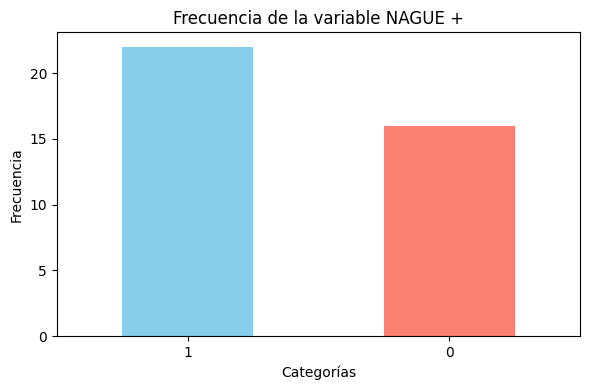

Frecuencias Post-Diálisis:
NAGUE +
0    26
1    12
Name: count, dtype: int64

Proporciones Post-Diálisis:
NAGUE +
0    0.684211
1    0.315789
Name: proportion, dtype: float64


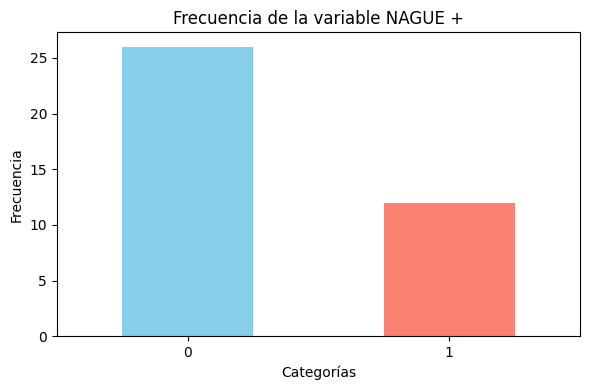

In [14]:
frecuencia_pre = df_pre['NAGUE +'].value_counts()
proporciones_pre = df_pre['NAGUE +'].value_counts(normalize=True)


frecuencia_pos = df_pos['NAGUE +'].value_counts()
proporciones_pos = df_pos['NAGUE +'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['NAGUE +'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable NAGUE +')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['NAGUE +'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable NAGUE +')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='NAGUE +').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.00195


Despues,0,1
Antes,,
0,16,0
1,10,12


## DisfTEI

Frecuencias Pre-Diálisis:
DisfTEI
1.0    26
0.0    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
DisfTEI
1.0    0.702703
0.0    0.297297
Name: proportion, dtype: float64


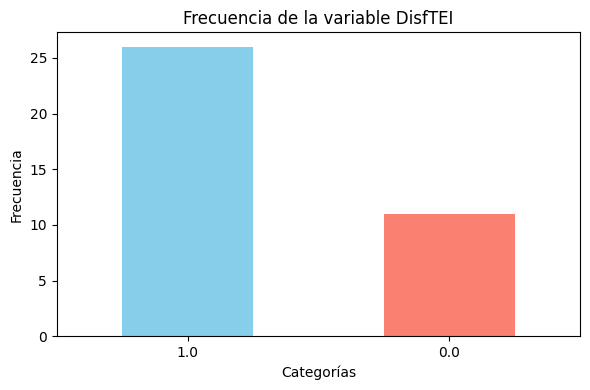

Frecuencias Post-Diálisis:
DisfTEI
1.0    23
0.0    14
Name: count, dtype: int64

Proporciones Post-Diálisis:
DisfTEI
1.0    0.621622
0.0    0.378378
Name: proportion, dtype: float64


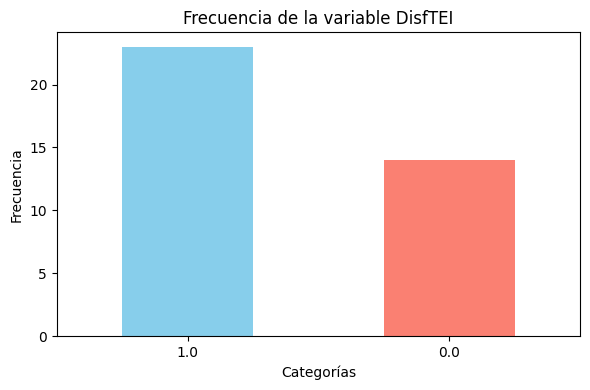

In [16]:
frecuencia_pre = df_pre['DisfTEI'].value_counts()
proporciones_pre = df_pre['DisfTEI'].value_counts(normalize=True)


frecuencia_pos = df_pos['DisfTEI'].value_counts()
proporciones_pos = df_pos['DisfTEI'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['DisfTEI'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable DisfTEI')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['DisfTEI'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable DisfTEI')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='DisfTEI').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.54883


Despues,0.0,1.0
Antes,,
0.0,7,4
1.0,7,19


## Disf TAPSE

Frecuencias Pre-Diálisis:
Disf TAPSE
1.0    32
0.0     5
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Disf TAPSE
1.0    0.864865
0.0    0.135135
Name: proportion, dtype: float64


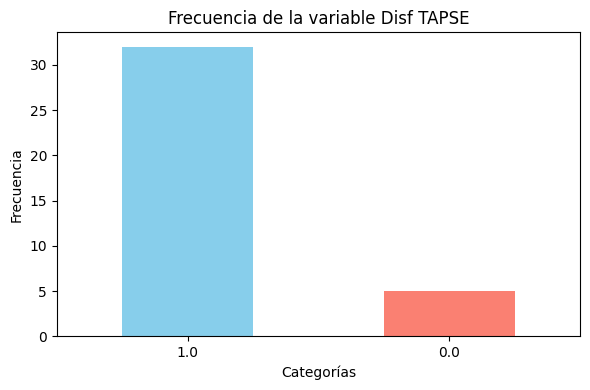

Frecuencias Post-Diálisis:
Disf TAPSE
1.0    29
0.0     8
Name: count, dtype: int64

Proporciones Post-Diálisis:
Disf TAPSE
1.0    0.783784
0.0    0.216216
Name: proportion, dtype: float64


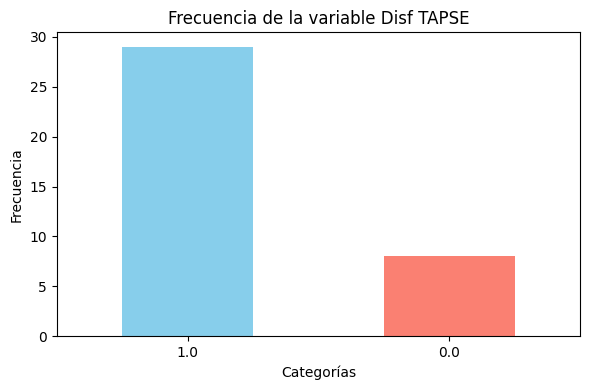

In [18]:
frecuencia_pre = df_pre['Disf TAPSE'].value_counts()
proporciones_pre = df_pre['Disf TAPSE'].value_counts(normalize=True)


frecuencia_pos = df_pos['Disf TAPSE'].value_counts()
proporciones_pos = df_pos['Disf TAPSE'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Disf TAPSE'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf TAPSE')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Disf TAPSE'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf TAPSE')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Corte en 17 -  Guia de evaluacion de cavidades derechas.Guidelines for echocardiographyc assasment of the rigth heart in adult. JASE 2010 

In [19]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Disf TAPSE').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.37500


Despues,0.0,1.0
Antes,,
0.0,4,1
1.0,4,28


## Disf FAC

Frecuencias Pre-Diálisis:
Disf FAC
1.0    32
0.0     4
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Disf FAC
1.0    0.888889
0.0    0.111111
Name: proportion, dtype: float64


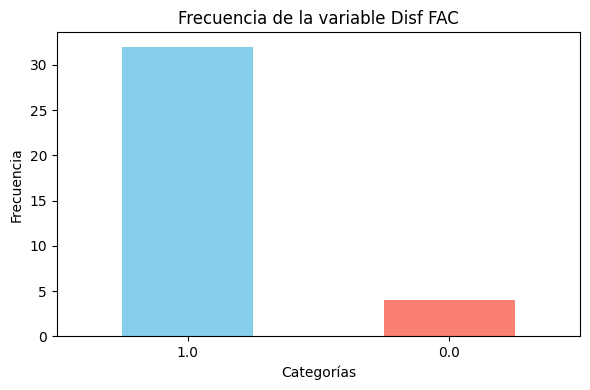

Frecuencias Post-Diálisis:
Disf FAC
1.0    30
0.0     6
Name: count, dtype: int64

Proporciones Post-Diálisis:
Disf FAC
1.0    0.833333
0.0    0.166667
Name: proportion, dtype: float64


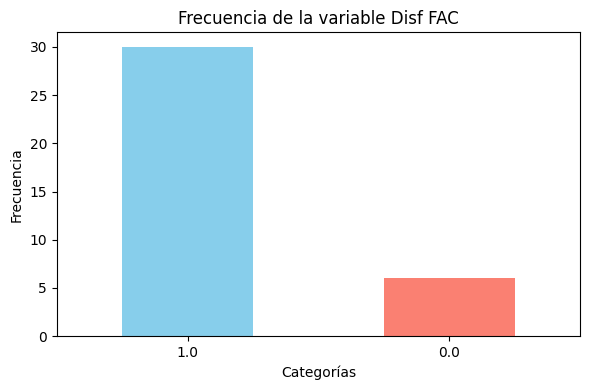

In [20]:
frecuencia_pre = df_pre['Disf FAC'].value_counts()
proporciones_pre = df_pre['Disf FAC'].value_counts(normalize=True)


frecuencia_pos = df_pos['Disf FAC'].value_counts()
proporciones_pos = df_pos['Disf FAC'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Disf FAC'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf FAC')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Disf FAC'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf FAC')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Disf FAC').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.62500


Despues,0.0,1.0
Antes,,
0.0,3,1
1.0,3,29


## Disf Stis

Frecuencias Pre-Diálisis:
Disf Stis
1.0    31
0.0     6
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Disf Stis
1.0    0.837838
0.0    0.162162
Name: proportion, dtype: float64


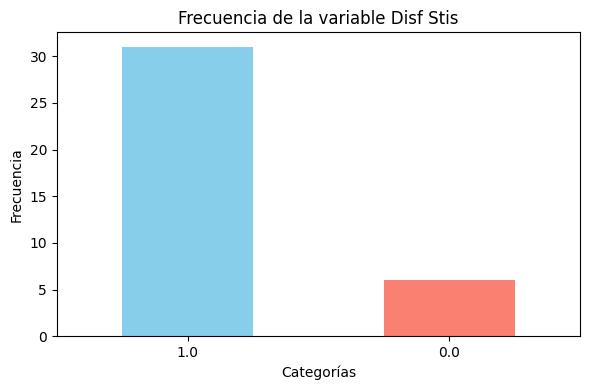

Frecuencias Post-Diálisis:
Disf Stis
1.0    24
0.0    13
Name: count, dtype: int64

Proporciones Post-Diálisis:
Disf Stis
1.0    0.648649
0.0    0.351351
Name: proportion, dtype: float64


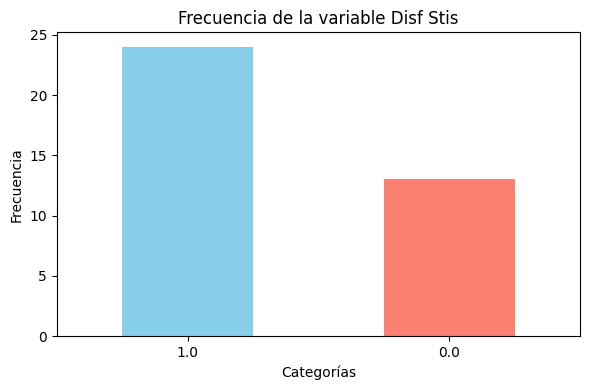

In [22]:
frecuencia_pre = df_pre['Disf Stis'].value_counts()
proporciones_pre = df_pre['Disf Stis'].value_counts(normalize=True)


frecuencia_pos = df_pos['Disf Stis'].value_counts()
proporciones_pos = df_pos['Disf Stis'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Disf Stis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Stis')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Disf Stis'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Stis')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Disf Stis').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.03906


Despues,0.0,1.0
Antes,,
0.0,5,1
1.0,8,23


## IT

Frecuencias Pre-Diálisis:
IT
1    24
0    12
2     1
3     1
Name: count, dtype: int64

Proporciones Pre-Diálisis:
IT
1    0.631579
0    0.315789
2    0.026316
3    0.026316
Name: proportion, dtype: float64


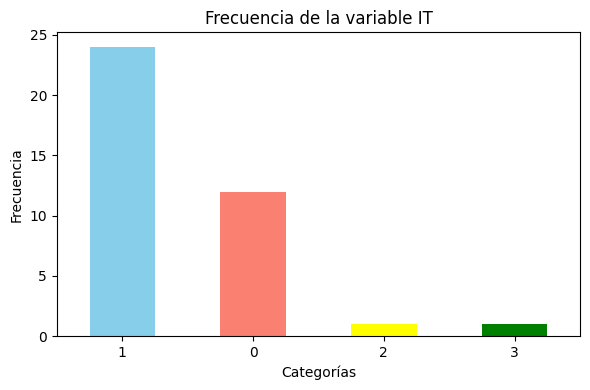

Frecuencias Post-Diálisis:
IT
0    20
1    16
2     1
3     1
Name: count, dtype: int64

Proporciones Post-Diálisis:
IT
0    0.526316
1    0.421053
2    0.026316
3    0.026316
Name: proportion, dtype: float64


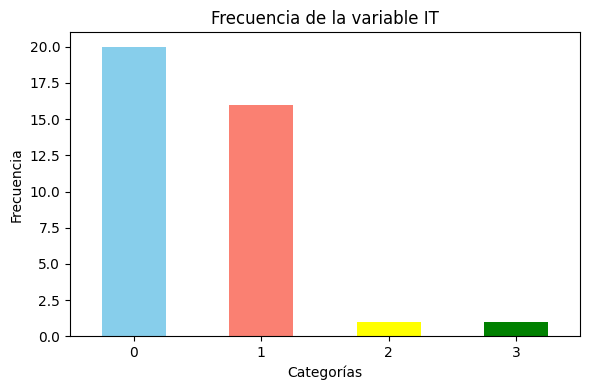

In [24]:

frecuencia_pre = df_pre['IT'].value_counts()
proporciones_pre = df_pre['IT'].value_counts(normalize=True)


frecuencia_pos = df_pos['IT'].value_counts()
proporciones_pos = df_pos['IT'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['IT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow', 'green'])
plt.title('Frecuencia de la variable IT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['IT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow', 'green'])
plt.title('Frecuencia de la variable IT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Leve, moderada, severa, sin it

In [25]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='IT').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.02148


Despues,0,1,2,3
Antes,,,,
0,11,1,0,0
1,9,15,0,0
2,0,0,1,0
3,0,0,0,1


## CAVA

In [26]:
df['CAVA'].value_counts()
# Sin dilatar colapsante 1, dilatada sin colapso 3, intermedia 2

CAVA
0    47
2    15
1    14
Name: count, dtype: int64

Frecuencias Pre-Diálisis:
CAVA
0    15
2    12
1    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
CAVA
0    0.394737
2    0.315789
1    0.289474
Name: proportion, dtype: float64


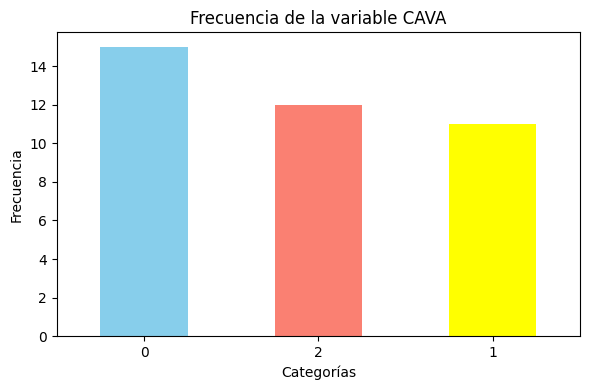

Frecuencias Post-Diálisis:
CAVA
0    32
2     3
1     3
Name: count, dtype: int64

Proporciones Post-Diálisis:
CAVA
0    0.842105
2    0.078947
1    0.078947
Name: proportion, dtype: float64


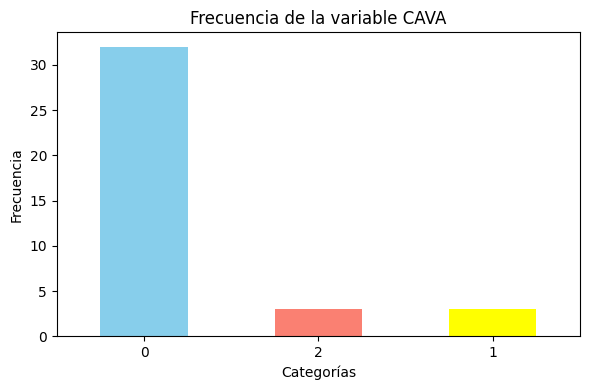

In [27]:
frecuencia_pre = df_pre['CAVA'].value_counts()
proporciones_pre = df_pre['CAVA'].value_counts(normalize=True)


frecuencia_pos = df_pos['CAVA'].value_counts()
proporciones_pos = df_pos['CAVA'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['CAVA'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable CAVA')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['CAVA'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable CAVA')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [28]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='CAVA').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.00098


Despues,0,1,2
Antes,,,
0,15,0,0
1,11,0,0
2,6,3,3


## PORT

Frecuencias Pre-Diálisis:
PORT
0    15
1    12
2    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
PORT
0    0.394737
1    0.315789
2    0.289474
Name: proportion, dtype: float64


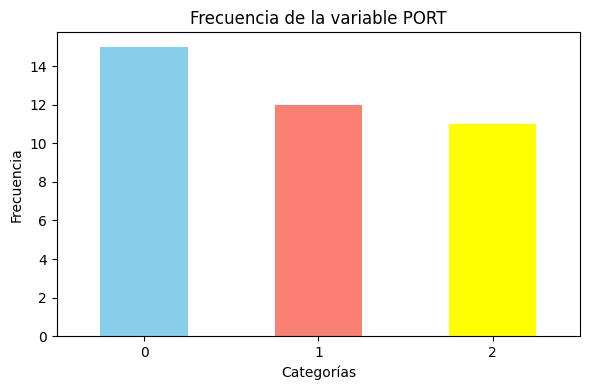

Frecuencias Post-Diálisis:
PORT
0    28
1     9
2     1
Name: count, dtype: int64

Proporciones Post-Diálisis:
PORT
0    0.736842
1    0.236842
2    0.026316
Name: proportion, dtype: float64


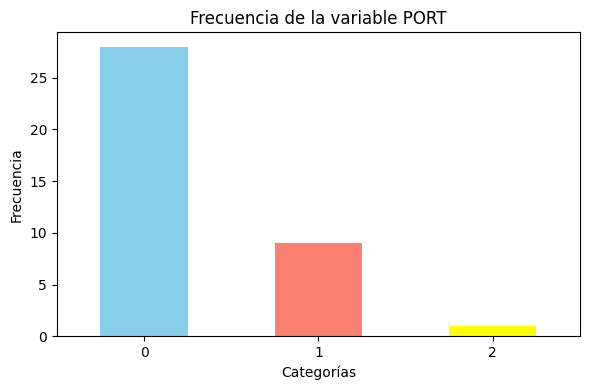

In [29]:


frecuencia_pre = df_pre['PORT'].value_counts()
proporciones_pre = df_pre['PORT'].value_counts(normalize=True)


frecuencia_pos = df_pos['PORT'].value_counts()
proporciones_pos = df_pos['PORT'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['PORT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable PORT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['PORT'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'yellow'])
plt.title('Frecuencia de la variable PORT')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [30]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='PORT').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.01562


Despues,0,1,2
Antes,,,
0,15,0,0
1,7,5,0
2,6,4,1


## Eeprim VD 6

In [31]:
df_pre['Eeprim VD 6'].value_counts()

Eeprim VD 6
1.0    26
0.0    11
Name: count, dtype: int64

Frecuencias Pre-Diálisis:
Eeprim VD 6
1.0    26
0.0    11
Name: count, dtype: int64

Proporciones Pre-Diálisis:
Eeprim VD 6
1.0    0.702703
0.0    0.297297
Name: proportion, dtype: float64


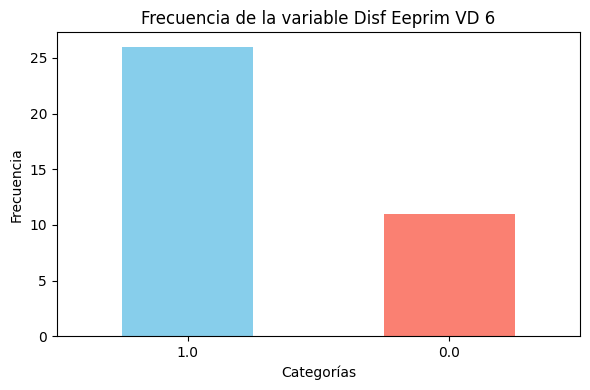

Frecuencias Post-Diálisis:
Eeprim VD 6
1.0    21
0.0    16
Name: count, dtype: int64

Proporciones Post-Diálisis:
Eeprim VD 6
1.0    0.567568
0.0    0.432432
Name: proportion, dtype: float64


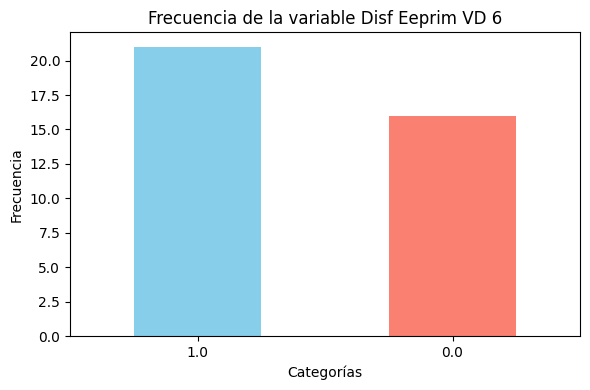

In [32]:
frecuencia_pre = df_pre['Eeprim VD 6'].value_counts()
proporciones_pre = df_pre['Eeprim VD 6'].value_counts(normalize=True)


frecuencia_pos = df_pos['Eeprim VD 6'].value_counts()
proporciones_pos = df_pos['Eeprim VD 6'].value_counts(normalize=True)

print("Frecuencias Pre-Diálisis:")
print(frecuencia_pre)
print("\nProporciones Pre-Diálisis:")
print(proporciones_pre)

# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pre['Eeprim VD 6'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Eeprim VD 6')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Frecuencias Post-Diálisis:")
print(frecuencia_pos)
print("\nProporciones Post-Diálisis:")
print(proporciones_pos)


# Gráfico de barras
plt.figure(figsize=(6, 4))
df_pos['Eeprim VD 6'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Frecuencia de la variable Disf Eeprim VD 6')
plt.xlabel('Categorías')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 1 significa mayor a 6

In [33]:
df_wide = df.pivot(index='Paciente', columns='POSDIAL', values='Eeprim VD 6').dropna()
df_wide.columns = ['Antes', 'Despues']

contingency_table = pd.crosstab(df_wide['Antes'], df_wide['Despues'])


result = mcnemar(contingency_table, exact=True)
print(f"\nPrueba de McNemar: p-valor = {result.pvalue:.5f}")

contingency_table


Prueba de McNemar: p-valor = 0.22656


Despues,0.0,1.0
Antes,,
0.0,8,3
1.0,8,18


# Variables Nméricas

In [51]:
missing_threshold = 1

no_numericas = var_estaticas + var_categoricas
initial_variables = df.drop(columns=no_numericas).columns.tolist()

missing_stats = []
for var in initial_variables:
    pre_missing = df[df['POSDIAL'] == 0][var].isna().mean()
    post_missing = df[df['POSDIAL'] == 1][var].isna().mean()
    max_missing = max(pre_missing, post_missing)
    missing_stats.append((var, max_missing))

variables_to_analyze = [var for var, missing in missing_stats if missing <= missing_threshold]

it_dependent_vars = [] # ['vel it', 'PSAP', 'TapPsap', 'grIT']
non_it_vars = [var for var in variables_to_analyze if var not in it_dependent_vars]

In [52]:
df['IT_status'] = df['IT'].apply(lambda x: 0 if x == 0 else 1)

In [53]:
scaler = StandardScaler()
df_z = df.copy()
df_z[var_numericas] = scaler.fit_transform(df[var_numericas])
df_z = df_z.add_suffix('_z') if len(var_numericas) > 0 else df.copy()

In [55]:


print("═"*60)
print(f"Variables excluidas por >{missing_threshold:.0%} missing:")
print(set(initial_variables) - set(variables_to_analyze))
print("═"*60)


def analyze_missing_data(df, variables, covariates):
    missing_summary = []
    for var in variables:
        if var in it_dependent_vars:
            valid_patients = df[df['IT_status'] == 1]['Paciente'].unique()
            temp_df = df[df['Paciente'].isin(valid_patients)]
        else:
            temp_df = df
        total_pacientes = df['Paciente'].nunique()
        pre_missing = temp_df[temp_df['POSDIAL'] == 0][var].isna().sum()
        post_missing = temp_df[temp_df['POSDIAL'] == 1][var].isna().sum()
        merged = df.pivot(index='Paciente', columns='POSDIAL', values=var).dropna()
        n_paired = len(merged)
        mcar_results = {}
        for covar in covariates:
            try:
                if df[covar].dtype == 'object' or df[covar].nunique() < 5:
                    contingency = pd.crosstab(df[var].isna(), df[covar])
                    _, pval, _, _ = chi2_contingency(contingency)
                else:
                    present_data = df[df[var].notna()][covar]
                    missing_data = df[df[var].isna()][covar]
                    _, pval = ttest_ind(present_data, missing_data, nan_policy='omit')
                mcar_results[covar] = f"{pval:.3f}"
            except:
                mcar_results[covar] = "Error"
        missing_summary.append({
            'Variable': var,
            'Pacientes Totales': total_pacientes,
            'Pre-Missing (%)': f"{(pre_missing/total_pacientes)*100:.1f}%",
            'Post-Missing (%)': f"{(post_missing/total_pacientes)*100:.1f}%",
            'Pares Completos': n_paired,
            **{f'MCAR_{covar}': mcar_results.get(covar, 'No Data') for covar in covariates},
            'Significativas (p<0.05)': sum(
                1 for v in mcar_results.values() if isinstance(v, str) and v.replace('.','').isdigit() and float(v) < 0.05)
        })
    return pd.DataFrame(missing_summary)


def calcular_tamano_muestra(df, variable, alpha=0.05, potencia=0.80):
    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()
    diffs = merged[1] - merged[0]
    
    if diffs.std(ddof=1) == 0:
        print(f"⚠ Varianza cero en {variable}. Tamaño de efecto indefinido.")
        return np.nan
    
    tamano_efecto = diffs.mean() / diffs.std(ddof=1)
    power_analysis = TTestPower()
    n = power_analysis.solve_power(effect_size=tamano_efecto, alpha=alpha, power=potencia, alternative='two-sided')

    return math.ceil(n)


def bootstrap_analysis(merged, n_iterations=1000):
    """Análisis de bootstrapping para diferencias pareadas usando scipy"""
    try:
        # Convertir a formato requerido por scipy bootstrap
        data = (merged[1].values, merged[0].values)  # (post, pre)

        # Definir estadístico: diferencia de medias post-pre
        def statistic(post, pre):
            return np.mean(post - pre)

        # Configurar bootstrap
        res = bootstrap(data, statistic, n_resamples=n_iterations,
                        paired=True, confidence_level=0.95,
                        method='BCa')

        return {
            'bootstrap_ci_lower': res.confidence_interval.low,
            'bootstrap_ci_upper': res.confidence_interval.high,
            'bootstrap_dist': res.bootstrap_distribution
        }
    except Exception as e:
        print(f"Error en bootstrapping: {str(e)}")
        return None

def mixed_model_analysis(df, variable):
    try:
        safe_var = variable.replace(" ", "_")
        df_clean = df.rename(columns={variable: safe_var}).dropna(subset=[safe_var])

        formula = f'Q("{safe_var}") ~ POSDIAL'

        model = mixedlm(formula,
                       df_clean,
                       groups=df_clean['Paciente'],
                       re_formula="1").fit(reml=True)

        return {
            'effect': model.params['POSDIAL'],
            'p_value': model.pvalues['POSDIAL'],
            'ci_lower': model.conf_int().loc['POSDIAL'][0],
            'ci_upper': model.conf_int().loc['POSDIAL'][1]
        }
    except Exception as e:
        print(f"Error en modelo mixto para {variable}: {str(e)}")
        return None

    
plt.style.use('ggplot')
sns.set_palette(["#2E86AB", "#D7263D"])

def paired_analysis(df, df_z, variable, min_paired=10, alpha=0.05, potencia=0.80, tamano_efecto=0.5):
    n_requerido = calcular_tamano_muestra(df, variable)

    merged = df.pivot(index='Paciente', columns='POSDIAL', values=variable).dropna()
    n = len(merged)

    if n < min_paired:
        print(f"\n⚠ {variable}: Datos insuficientes (n={n})")
        return

    merged_z = df_z.pivot(index='Paciente_z', columns='POSDIAL_z', values=f"{variable}_z").dropna()
    pre, post = merged[0], merged[1]
    pre_z, post_z = merged_z[0], merged_z[1]
    diffs, diffs_z = post - pre, post_z - pre_z

    norm_flag = "[Normalizada] " if variable in variables_ else ""
    mean_diff_z, sd_diff_z = diffs_z.mean(), diffs_z.std(ddof=1)
    t_critical = t.ppf(0.975, df=n-1)
    ci_lower_z = mean_diff_z - t_critical * (sd_diff_z/np.sqrt(n))
    ci_upper_z = mean_diff_z + t_critical * (sd_diff_z/np.sqrt(n))
    cohen_d_z = mean_diff_z / sd_diff_z

    # 1. Modelo de efectos mixtos
    mixed_results = mixed_model_analysis(df, variable)

    # 2. Bootstrapping con scipy
    bootstrap_results = bootstrap_analysis(merged) if n >= 10 else None

    # 3. Comparación con variables completas (Eeprim)
    referencia_results = None
    if 'Eeprim' in variables_to_analyze and variable != 'Eeprim':
        ref_merged = df.pivot(index='Paciente', columns='POSDIAL', values='Eeprim').dropna()
        referencia_results = bootstrap_analysis(ref_merged)

    # Construir texto de resultados
    sensibilidad_text = f"""
    🔍 ANÁLISIS DE SENSIBILIDAD - {variable.upper()}
    ▪ Modelo mixto: β = {mixed_results['effect']:.2f} (IC95% {mixed_results['ci_lower']:.2f}-{mixed_results['ci_upper']:.2f}, p={mixed_results['p_value']:.4f})""" if mixed_results else ""

    if bootstrap_results:
        sensibilidad_text += f"""
    ▪ Bootstrapping BCa (IC95%): [{bootstrap_results['bootstrap_ci_lower']:.2f}, {bootstrap_results['bootstrap_ci_upper']:.2f}]"""

    if referencia_results:
        sensibilidad_text += f"""
    ▪ Referencia (Eeprim): IC95% bootstrap = [{referencia_results['bootstrap_ci_lower']:.2f}, {referencia_results['bootstrap_ci_upper']:.2f}]"""

    print(sensibilidad_text)

    # Advertencias sobre sesgo
    n_total = df['Paciente'].nunique()
    n_missing = n_total - n
    if n_missing > 0:
        print(f"""
    ⚠ ADVERTENCIAS:
    - {n_missing}/{n_total} pacientes excluidos ({n_missing/n_total:.1%})
    - Diferencias significativas en covariables:""")

        missing_patients = set(df['Paciente']) - set(merged.index)
        df_incluidos = df[~df['Paciente'].isin(missing_patients)]
        df_excluidos = df[df['Paciente'].isin(missing_patients)]

        for cov in covariates:
            try:
                if pd.api.types.is_numeric_dtype(df[cov]):
                    stat, pval = ttest_ind(
                        df_incluidos[cov].dropna(),
                        df_excluidos[cov].dropna(),
                        equal_var=False
                    )
                else:
                    cont_table = pd.crosstab(
                        df['Paciente'].isin(missing_patients),
                        df[cov]
                    )
                    _, pval, _, _ = chi2_contingency(cont_table)

                if pval < 0.1:
                    print(f"    - {cov}: p={pval:.3f}")
            except:
                continue

    print('─'*80)



    shapiro_stat, shapiro_p = shapiro(diffs_z)
    X = sm.add_constant(pre)
    modelo = sm.OLS(post, X).fit()
    beta0, beta1 = modelo.params
    r2 = modelo.rsquared
    
    X_balance = pd.DataFrame({
    'pre': pre,
    'balance': df.loc[pre.index, 'BALANCE']  # Asumiendo BALANCE es por paciente
        })
    X_balance = sm.add_constant(X_balance)
    modelo_balance = sm.OLS(post, X_balance).fit()

    fig, axs = plt.subplots(1, 4, figsize=(24, 6), dpi=100)
    fig.suptitle(f"{norm_flag}{variable.upper()} (n={n})", fontsize=16, y=1.05, fontweight='bold')

    sns.histplot(pre, ax=axs[0], color='#2E86AB', kde=True, edgecolor='w', alpha=0.6, label='Pre')
    sns.histplot(post, ax=axs[0], color='#D7263D', kde=True, edgecolor='w', alpha=0.6, label='Post')
    axs[0].axvline(pre.mean(), color='#2E86AB', linestyle='--', linewidth=1.5)
    axs[0].axvline(post.mean(), color='#D7263D', linestyle='--', linewidth=1.5)
    axs[0].set_title('Distribución de Valores')
    axs[0].legend()

    melted = pd.melt(merged.reset_index(), id_vars='Paciente', value_vars=[0,1], var_name='Tiempo', value_name='Valor')
    sns.boxplot(x='Tiempo', y='Valor', data=melted, ax=axs[1], width=0.5, linewidth=1.5, hue='Tiempo')
    axs[1].set_xticks([0, 1])
    axs[1].set_xticklabels(['Pre-Diálisis', 'Post-Diálisis'], fontweight='bold', rotation=45)
    sns.swarmplot(x='Tiempo', y='Valor', data=melted, ax=axs[1], color='#333333', size=4, alpha=0.7)
    axs[1].set_title('Comparación Pre-Post')
    axs[1].grid(True, alpha=0.3)

    min_val, max_val = min(pre.min(), post.min()), max(pre.max(), post.max())
    x_pred = np.linspace(min_val, max_val, 100)
    X_pred = sm.add_constant(x_pred)
    y_pred = modelo.predict(X_pred)
    pred_int = modelo.get_prediction(X_pred).conf_int()
    palette = sns.diverging_palette(250, 10, sep=80, as_cmap=True)
    vmax = max(abs(diffs.max()), abs(diffs.min()))
    scatter = axs[2].scatter(pre, post, c=diffs, cmap=palette, vmin=-vmax, vmax=vmax, edgecolor='k', s=80)
    plt.colorbar(scatter, ax=axs[2], shrink=0.8).set_label('Diferencia (Post-Pre)')
    axs[2].plot([min_val, max_val], [min_val, max_val], '--', color='gray', label="Identidad")
    axs[2].plot(x_pred, y_pred, color='#6C757D', linewidth=2, label="Regresión")
    axs[2].fill_between(x_pred, pred_int[:,0], pred_int[:,1], color='#AAB2BD', alpha=0.3, label="IC 95%")
    axs[2].text(0.05, 0.15, 
            f'R² (pre): {r2:.2f}\nR² (+balance): {modelo_balance.rsquared:.2f}',
            transform=axs[2].transAxes,
            bbox=dict(facecolor='white', alpha=0.8))
    axs[2].set_title('Concordancia Pre-Post')
    axs[2].legend()

    avg = (pre + post)/2
    mean_diff = diffs.mean()
    std_diff = diffs.std(ddof=1)
    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    sns.scatterplot(x=avg, y=diffs, ax=axs[3], color='#2E86AB', s=60, alpha=0.7)
    axs[3].axhline(mean_diff, color='#D7263D', linestyle='--', linewidth=1.5)
    axs[3].axhline(upper_loa, color='gray', linestyle=':', linewidth=1.2)
    axs[3].axhline(lower_loa, color='gray', linestyle=':', linewidth=1.2)
    axs[3].text(0.05, 0.95, f'Bias: {mean_diff:.2f}\nLímites: ±{1.96*std_diff:.2f}',
                transform=axs[3].transAxes, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
    axs[3].set_title('Bland-Altman')
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if shapiro_p > 0.05:
        test_result = ttest_rel(pre_z, post_z)
        test_type = f"t({n-1}) = {test_result.statistic:.2f}, p = {test_result.pvalue:.4f}"
    else:
        test_result = wilcoxon(pre_z, post_z, mode='approx')
        Z = (test_result.statistic - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)
        test_type = f"Z = {Z:.3f}, p = {test_result.pvalue:.4f}"

    print(f"""
    📊 ANÁLISIS ESTADÍSTICO - {variable.upper()}
    ▪ Diferencia media (IC 95%) [Estandarizada]: {mean_diff_z:.2f} ({ci_lower_z:.2f} a {ci_upper_z:.2f})
    ▪ Diferencia media (IC 95%) [Original]: {diffs.mean():.2f} ({diffs.mean()-1.96*diffs.std()/np.sqrt(n):.2f} a {diffs.mean()+1.96*diffs.std()/np.sqrt(n):.2f})
    ▪ Prueba de normalidad: W = {shapiro_stat:.3f}, p = {shapiro_p:.4f}
    ▪ Prueba seleccionada: {test_type}
    ▪ Tamaño del efecto (Cohen's d): {cohen_d_z:.2f}
    ▪ R² (solo pre): {r2:.3f}
    ▪ R² (pre + balance): {modelo_balance.rsquared:.3f}
    ▪ Tamaño de muestra requerido para detectar un efecto significativo en {variable}: {n_requerido} pacientes.
    """)
    print('─'*80)

missing_df = analyze_missing_data(df, variables_to_analyze, categorical_vars)
print("\n[ANÁLISIS DE VALORES PERDIDOS - VARIABLES INCLUIDAS]")
print(tabulate(missing_df, headers='keys', tablefmt='pretty', showindex=False))

print("ANÁLISIS LONGITUDINAL PAREADO")
print("═"*60)
for var in var_numericas:
    paired_analysis(df, df_z, var)

════════════════════════════════════════════════════════════
Variables excluidas por >100% missing:
set()
════════════════════════════════════════════════════════════

[ANÁLISIS DE VALORES PERDIDOS - VARIABLES INCLUIDAS]
+--------------+-------------------+-----------------+------------------+-----------------+----------+----------+----------+----------+----------+----------+---------+----------+-----------+-------------+-----------+----------+-----------+---------------+-------------------------+
|   Variable   | Pacientes Totales | Pre-Missing (%) | Post-Missing (%) | Pares Completos | MCAR_SEX | MCAR_HTA | MCAR_DBT | MCAR_DLP | MCAR_AHF | MCAR_TBQ | MCAR_BB | MCAR_BCA | MCAR_IECA | MCAR_ARA II | MCAR_ARNI | MCAR_MRA | MCAR_SGLT | MCAR_INSULINA | Significativas (p<0.05) |
+--------------+-------------------+-----------------+------------------+-----------------+----------+----------+----------+----------+----------+----------+---------+----------+-----------+-------------+-----------

KeyError: 0

# MATERIALES Y *METODOS*

**2.4. Manejo de Datos y Análisis Estadístico**

*2.4.1. Preprocesamiento:*

*Valores faltantes:* 

Mediante análisis multivariado (Missing Completely at Random, MCAR), se evaluó la asociación de datos faltantes con variables clínicas clave (hipertensión, diabetes, sexo, dislipidemia) usando pruebas χ² (categóricas) y t-test (continuas). Variables con >30% faltantes en cualquier momento (pre/post) se excluyeron del análisis longitudinal.

*Normalización:*

Variables con unidades no directamente interpretables (e.g., índices ecocardiográficos derivados) se estandarizaron mediante escalado Z.
2.4.2. Análisis Estadístico:

*Normalidad:*

Evaluada con prueba de Shapiro-Wilk (α=0.05).

*Comparaciones pre-post:*

t-test pareado (datos normales) o prueba de Wilcoxon (no paramétricos), aplicados a datos estandarizados para homogenizar escalas.

*Tamaño del efecto:*

Cohen’s d en escala estandarizada (d=0.2: pequeño; d=0.5: moderado; d≥0.8: grande).

*Concordancia:*

Modelos de regresión lineal con IC 95% y gráficos de Bland-Altman (límites de acuerdo: ±1.96 DE).

*Visualización:* Histogramas superpuestos, diagramas de caja con swarmplots, y análisis de tendencia.

**2.4.3. Consideraciones Éticas y Software:**

Los datos se anonimizaron asignando identificadores únicos no vinculables. El análisis se implementó en Python 3.10 (SciPy v1.11, pandas v2.0.3, statsmodels v0.14), con visualización en matplotlib v3.7.1 y seaborn v0.12.2. El código cumple estándares FAIR y está disponible en [repositorio].